In [72]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [75]:
import pandas as pd
import numpy as np

#1.Cargar las campañas (CSV)
df_bank = pd.read_csv('../datos/bank-additional.csv')

#2.Cargar el Excel leyendo automáticamente los nombres de las pestañas
excel_path = '../datos/customer-details.xlsx'
xls = pd.ExcelFile(excel_path)
nombres_hojas = xls.sheet_names

#3.Cargar cada pestaña
df_hoja1 = pd.read_excel(excel_path, sheet_name=nombres_hojas[0])
df_hoja2 = pd.read_excel(excel_path, sheet_name=nombres_hojas[1])
df_hoja3 = pd.read_excel(excel_path, sheet_name=nombres_hojas[2])

#4.Juntar las 3 hojas en un único DataFrame de clientes
df_customers = pd.concat([df_hoja1, df_hoja2, df_hoja3], ignore_index=True)

#5.Mostrar en pantalla una muestra real de las campañas
print("=== VISTA PREVIA DE LAS CAMPÁÑAS (df_bank) ===")
display(df_bank.head(3))

#6.Mostrar en pantalla una muestra real de los clientes
print("\n=== VISTA PREVIA DE LOS CLIENTES (df_customers) ===")
display(df_customers.head(3))

=== VISTA PREVIA DE LAS CAMPÁÑAS (df_bank) ===


,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b



=== VISTA PREVIA DE LOS CLIENTES (df_customers) ===


,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b


In [76]:
#1.Eliminar la columna innecesaria 'Unnamed: 0' si existe
if 'Unnamed: 0' in df_bank.columns:
    df_bank = df_bank.drop(columns=['Unnamed: 0'])

#2.Arreglar las columnas numéricas que tienen comas en lugar de puntos
columnas_con_coma = ['cons.price.idx', 'cons.conf.idx', 'euribor3m']

for col in columnas_con_coma:
    if col in df_bank.columns:
        #Cambiamos la coma por punto y lo convertimos a número (float)
        df_bank[col] = df_bank[col].astype(str).str.replace(',', '.').astype(float)

#3.Estandarizar los nombres de los IDs para poder unirlos
df_customers = df_customers.rename(columns={'ID': 'id_'})

#Limpiar espacios invisibles en los IDs por si acaso
df_bank['id_'] = df_bank['id_'].astype(str).str.strip()
df_customers['id_'] = df_customers['id_'].astype(str).str.strip()

#4.¡Hacer la gran unión de los datos! (Merge)
df_final = pd.merge(df_bank, df_customers, on='id_', how='inner')

#5.Comprobar el resultado final
print("=== ¡UNIÓN Y LIMPIEZA INICIAL COMPLETADA! ===")
print(f"Dimensiones de la nueva tabla maestra (df_final): {df_final.shape}")
print("\nColumnas listas para analizar:")
print(df_final.columns.tolist())

=== ¡UNIÓN Y LIMPIEZA INICIAL COMPLETADA! ===
Dimensiones de la nueva tabla maestra (df_final): (43000, 29)

Columnas listas para analizar:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'date', 'latitude', 'longitude', 'id_', 'Unnamed: 0', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'NumWebVisitsMonth']


In [77]:
#1.Calcular cuántos nulos hay por columna y su porcentaje
valores_nulos = df_final.isnull().sum()
porcentaje_nulos = (df_final.isnull().sum() / len(df_final)) * 100

#2.Juntar ambos datos en una tablita para verlo claro
tabla_nulos = pd.DataFrame({'Total Nulos': valores_nulos, 'Porcentaje (%)': porcentaje_nulos})

#3.Filtrar para mostrar solo las columnas que SÍ tienen nulos (ordenadas de mayor a menor)
tabla_nulos = tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)

print("=== COLUMNAS CON VALORES FALTANTES ===")
display(tabla_nulos)

=== COLUMNAS CON VALORES FALTANTES ===


,Total Nulos,Porcentaje (%)
euribor3m,9256,21.525581
default,8981,20.886047
age,5120,11.906977
education,1807,4.202326
loan,1026,2.386047
housing,1026,2.386047
cons.price.idx,471,1.095349
job,345,0.802326
date,248,0.576744
marital,85,0.197674


In [78]:
#1.Rellenar variables numéricas con su mediana
df_final['age'] = df_final['age'].fillna(df_final['age'].median())
df_final['euribor3m'] = df_final['euribor3m'].fillna(df_final['euribor3m'].median())

#2.Rellenar variables categóricas con su moda (el valor más común)
columnas_categoricas_nulas = ['marital', 'housing', 'loan', 'default']

for col in columnas_categoricas_nulas:
    #.mode()[0] extrae el valor de texto más frecuente de esa columna
    moda_columna = df_final[col].mode()[0]
    df_final[col] = df_final[col].fillna(moda_columna)

#3.Verificar si todavía queda algún nulo en todo el DataFrame
print("=== COMPROBACIÓN DE NULOS POST-LIMPIEZA ===")
print(f"Total de valores nulos restantes en el dataset: {df_final.isnull().sum().sum()}")

=== COMPROBACIÓN DE NULOS POST-LIMPIEZA ===
Total de valores nulos restantes en el dataset: 2871


Resumen

In [79]:
# 1.Resumen estadístico de las variables numéricas principales
print("=== RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ===")
#Seleccionamos las columnas demográficas y económicas más importantes
columnas_num = ['age', 'Income', 'Kidhome', 'Teenhome', 'NumWebVisitsMonth', 'campaign', 'euribor3m']
display(df_final[columnas_num].describe().T)

print("\n" + "="*50 + "\n")

#2.Resumen de las variables de texto clave (Profesión y éxito de la campaña)
print("=== DISTRIBUCIÓN DE LAS OCUPACIONES (Categorías) ===")
print(df_final['job'].value_counts())

print("\n" + "="*50 + "\n")

print("=== BALANCE DE LA VARIABLE OBJETIVO (¿Suscrito al depósito? 'y') ===")
print(df_final['y'].value_counts(normalize=True) * 100)

=== RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ===


,count,mean,std,min,25%,50%,75%,max
age,43000.0,39.741698,9.817735,17.000,33.000,38.000,46.000,98.000
Income,43000.0,93241.200070,50498.316182,5841.000,49610.000,93050.500,136744.500,180802.000
Kidhome,43000.0,1.004791,0.815913,0.000,0.000,1.000,2.000,2.000
Teenhome,43000.0,0.998605,0.815983,0.000,0.000,1.000,2.000,2.000
NumWebVisitsMonth,43000.0,16.589698,9.239205,1.000,9.000,17.000,25.000,32.000
campaign,43000.0,2.567233,2.772294,1.000,1.000,2.000,3.000,56.000
euribor3m,43000.0,3.883541,1.621095,0.634,1.466,4.857,4.959,5.045




=== DISTRIBUCIÓN DE LAS OCUPACIONES (Categorías) ===
job
admin.           10873
blue-collar       9654
technician        7026
services          4162
management        3050
retired           1790
entrepreneur      1522
self-employed     1489
housemaid         1123
unemployed        1063
student            903
Name: count, dtype: int64


=== BALANCE DE LA VARIABLE OBJETIVO (¿Suscrito al depósito? 'y') ===
y
no     88.734884
yes    11.265116
Name: proportion, dtype: float64


In [80]:
pip install matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for matplotlib.pyplot


In [81]:
pip install seaborn as sns

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for as



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


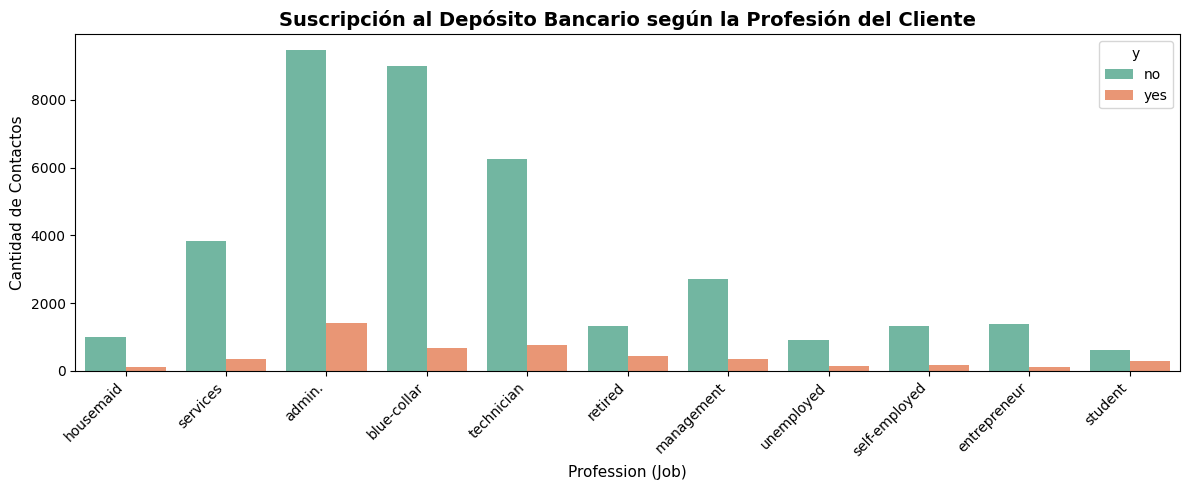

In [82]:
#1.Forzar la instalación de las librerías de gráficos en este entorno
%pip install matplotlib seaborn

#2.Una vez instaladas, las importamos
import matplotlib.pyplot as plt
import seaborn as sns

#3.Dibujamos el gráfico
plt.figure(figsize=(12, 5))
sns.countplot(data=df_final, x='job', hue='y', palette='Set2')
plt.title('Suscripción al Depósito Bancario según la Profesión del Cliente', fontsize=14, fontweight='bold')
plt.xlabel('Profession (Job)', fontsize=11)
plt.ylabel('Cantidad de Contactos', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\orlan\AppData\Local\Temp\ipykernel_364\3061347973.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='y', y='Income', palette='Pastel1')


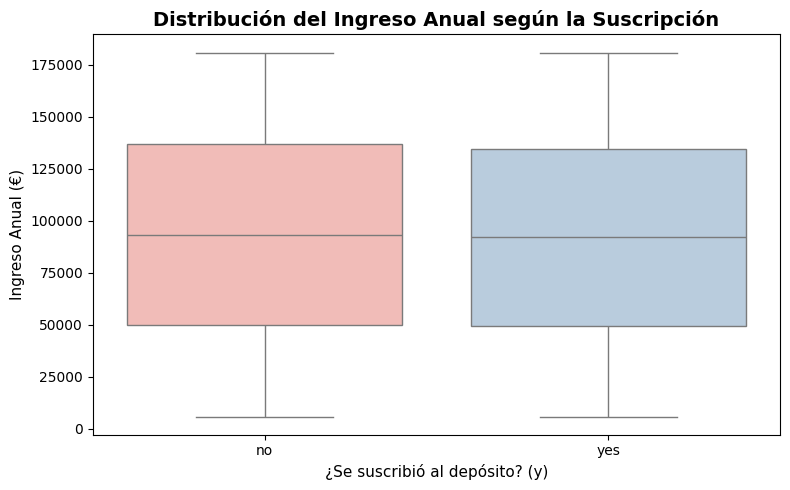

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

#Configurar el tamaño del segundo gráfico
plt.figure(figsize=(8, 5))

#Crear el gráfico de caja (Boxplot) para comparar ingresos según el éxito ('y')
sns.boxplot(data=df_final, x='y', y='Income', palette='Pastel1')

#Añadir títulos y etiquetas claras
plt.title('Distribución del Ingreso Anual según la Suscripción', fontsize=14, fontweight='bold')
plt.xlabel('¿Se suscribió al depósito? (y)', fontsize=11)
plt.ylabel('Ingreso Anual (€)', fontsize=11)

#Mostrar el gráfico
plt.tight_layout()
plt.show()

In [87]:
#Guardar el dataset final de forma limpia
df_final.to_csv('analisis_exploratorio.csv', index=False)

#El mensaje de éxito va en la línea de abajo
print("=== ¡ÉXITO! ===")
print("El archivo 'analisis_exploratorio.csv' se ha guardado correctamente.")

=== ¡ÉXITO! ===
El archivo 'analisis_exploratorio.csv' se ha guardado correctamente.
